---
title: Hidden Markov Model with Control (Part 1)
subtitle: Control a Roomba using Active Inference and RxInfer
author: Kobus Esterhuysen
date: '2024-05-10'
date-modified: last-modified
categories:
  - Bayesian Inference
  - Active Inference
  - RxInfer
  - Julia
image: HMMwithControl.png
format:
  html:
    toc: true
    toc-depth: 4
    toc-expand: true
    toc-title: TOC
    code-fold: false
---

In [ ]:
#| hide
# BASED ON
  # HMMwithControl_PORT^v2.ipynb
  # HMMwithControl_PORT^v1.ipynb
  # Hidden Markov Model_ANNO^v5.ipynb
    
# DONE
# v2 starts ------------------------------------------------
# Upgrade to latest Julia (1.10.4)
# Upgrade to latest RxInfer (3.6.0)
# v3 starts ------------------------------------------------
# DeVries --> Namjoshi
# change x --> o (for observation)
# tildes --> * for true quantities
# remove all underscores indicating globals
# add underscores for bold symbols which have spatial structure
# add ː (\lmrk) for time-sequences
# migrate to cursor & github
# WRONG !!! The 1-hotness does not count as a spatial structure
#     it HAS to have spatial structure coz gets multiplies by a matrix
#     similar to $\hat{y}$ with continuous Dirac-delta sample
#     everything is 1-hot for signals in discrete AIF
#     everything is BOLD in discrete AIF
#         components (state factors or observation modalities) of vectors will be \boldsymbol
#         matrices for factors/modalities will be \boldsymbol
#         compound vectors (state vector or observation vector) will be \mathbf
#         compound matrices (factors/modalities) will be \mathbf
# _oᴿᵒᵒᵐ --> _oᵀᵉˣᵗᵘʳᵉ
# clean for publication

# TODO


# Hidden Markov Model with Control (Part 1)

## 1 BUSINESS UNDERSTANDING

This is the first part of an effort to add control to the *Hidden Markov Model* RxInfer example. Eventually this work will be used in a more elaborate scheduling project making use of active inference.

In this part, we will simply be tracking a Roomba as it moves throughout a 3-bedroom apartment consisting of a master bedroom, a living room, and a bathroom. In addition, we start to wrap the original functionality with the usual structure:

- `create_envir()`
    - `execute()`
    - `observe()`
- `create_agent()`
    - `act()` [not yet]
    - `future()` [not yet]
    - `compute()`
    - `slide()` [not yet]

In the `compute()` function, which takes care of inference, we will estimate the $A$ and $B$ matrices. We also flipped the roles of these matrices to align with the neuroscience literature (rather than the engineering literature where $A$ is always used for system transitions).

In [1]:
versioninfo() ## Julia version

Julia Version 1.11.6
Commit 9615af0f269 (2025-07-09 12:58 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LLVM: libLLVM-16.0.6 (ORCJIT, skylake)
Threads: 1 default, 0 interactive, 1 GC (on 12 virtual cores)


In [1]:
import Pkg
Pkg.add(Pkg.PackageSpec(;name="RxInfer", version="3.6.0"))
Pkg.add(Pkg.PackageSpec(;name="Random"))
Pkg.add(Pkg.PackageSpec(;name="Plots", version="1.40.1"))
Pkg.add(Pkg.PackageSpec(;name="XLSX"))
Pkg.add(Pkg.PackageSpec(;name="DataFrames"))
Pkg.add(Pkg.PackageSpec(;name="BenchmarkTools"))
Pkg.add(Pkg.PackageSpec(;name="Distributions"))

using RxInfer, Random, BenchmarkTools, Distributions, Plots, XLSX, DataFrames

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.to

In [ ]:
Pkg.status()

Status `~/.julia/environments/v1.11/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [a93c6f00] DataFrames v1.8.2
  [31c24e10] Distributions v0.25.131
⌃ [91a5bcdd] Plots v1.40.1
⌃ [86711068] RxInfer v3.6.0
  [fdbf4ff8] XLSX v0.12.3
  [9a3f8284] Random v1.11.0
Info Packages marked with ⌃ have new versions available and may be upgradable.


## 2 DATA UNDERSTANDING

The data will consist of a time-series of 1-hot encoded position states. When the associated component of the state vector is a 1, the Roomba will be present in the associated room.

## 3 DATA PREPARATION

We will use the data from the simulation directly. There is no need to perform additional data preparation.

## 4 MODELING

### 4.1 Narrative

In general, we will have the following symbol conventions:

- $t$: time
- $k$: future time
- $l$: past time
- $x_t$: scalar random variable
- $x_{:,t}$: sequence of scalar random variables
- $\boldsymbol{x}_t$: 1-hot vector random variable
- $\boldsymbol{x_:}_{,t}$: sequence of 1-hot vector random variables
- $\mathbf{x}_t$: 1-hot compound vector random variable
- $\mathbf{x_:}_{,t}$: sequence of 1-hot compound vector random variables

### 4.2 Core Elements

This section attempts to answer three important questions:

- What metrics are we going to track?
- What decisions do we intend to make?
- What are the sources of uncertainty?

The only metric we are interested in is the postition of the Roomba, i.e. in which of the 3 rooms it finds itself. 

There are no control/steering decisions to be made (yet). We are simply interested in the behavior of the Roomba.

There are two sources of uncertainty. The first has to do with the fact that the state transitions are not deterministic but rather stochastic. This will be captured in the compound state transition matrix $\mathbf{B}$. State transitions for each *state factor* will be captured in a $\boldsymbol{B}[n]$ matrix where $n$ is the index of the state factor.

The second relates to observations. The Roomba does not always measure accurately the floor surface in a room. This uncertainty will be captured in the compound observation generation matrix $\boldsymbol{A}$. Observation generations for each *observation modality* will be captured in a $\boldsymbol{A}[m]$ matrix where $m$ is the index of the observation modality.

### 4.3 System-Under-Steer / Environment / Generative Process

First, in order to track the Roomba's movements using `RxInfer`, we need to come up with a model. Since we have a discrete set of rooms in the apartment, we can use a categorical distribution to represent the Roomba's position. There are three  rooms in the apartment, meaning we need three states in our categorical distribution. At time $t$, let's call the Roomba's true position:
$$
\begin{aligned}
\mathbf{s}^*_t &= (\boldsymbol{s}^{*\mathrm{Room}}_{t})
\end{aligned}
$$
where the *state factors* are:

- $\boldsymbol{s}^{*\mathrm{Room}}_{t} \in \{\text{bedroom}, \text{livingroom}, \text{bathroom} \}$

However, we also know that some rooms are more accessible than others, meaning the Roomba is more likely to move between these rooms - for example, it's rare to have a door directly between the bathroom and the master bedroom. We can encode this information using a (compound) transition matrix $\mathbf{B}^*$, which will be, for this single state factor, $\boldsymbol{B}^*[0]$.

Our Roomba is equipped with a small camera that tracks the surface it is moving over. We will use this camera to obtain our observations since we know that there is

- hardwood floors in the master bedroom
- carpet in the living room, and
- tiles in the bathroom. 

However, this method is not foolproof, and sometimes the Roomba will make mistakes and mistake the hardwood floor for tiles or the carpet for hardwood. Don't be too hard on the little guy, it's just a Roomba after all.

At time $t$, we will call our observation vector $\mathbf{o}_t$ and encode the mapping from the Roomba's position to the observations in a (compound) matrix $\mathbf{A}^*$ which will be, for this single observation modality, $\boldsymbol{A}^*[m]$. $\boldsymbol{A}^*[m]$ also encodes the likelihood that the Roomba will make a mistake and get the wrong observation. This leaves us with the following model specification:

$$
\begin{aligned}
    \boldsymbol{s}^{*\mathrm{Room}}_{t} & \sim \mathcal{C}at(\boldsymbol{B}^*[0] \boldsymbol{s}^{*\mathrm{Room}}_{t-1}),\\
    \boldsymbol{o}^{\mathrm{Texture}}_t & \sim \mathcal{C}at(\boldsymbol{A}^*[0] \boldsymbol{s}^{*\mathrm{Room}}_t).\\
\end{aligned}
$$

This type of discrete state space model is known as a *Hidden Markov Model* or HMM for short. Our goal is to learn the matrices $\boldsymbol{A}^*[0]$ and $\boldsymbol{B}^*[0]$ so we can use them to track the whereabouts of our little cleaning agent.

In [2]:
# _sˣ₀ = [1.0, 0.0, 0.0] ## initial state
_sˣᴿᵒᵒᵐ₀ = [1.0, 0.0, 0.0] ## initial state

3-element Vector{Float64}:
 1.0
 0.0
 0.0

#### 4.3.1 State and Observation variables

The *state variables* represent *what we need to know*. The true state at time $t$ of the Roomba will be given by a (compound) vector $\mathbf{s}^*_t$ consisting of 1-hot encoded state factor components (here a single component)

$$
\begin{aligned}
\mathbf{s}^*_t &= (\boldsymbol{s}^{*\mathrm{Room}}_{t})
\end{aligned}
$$

where the *state factors* are:

- $\boldsymbol{s}^{*\mathrm{Room}}_{t} \in \{\text{bedroom}, \text{livingroom}, \text{bathroom} \} = \{(1, 0, 0), (0, 1, 0), (0, 0, 1) \}$

Similarly, the (compound) observation vector for the Roomba at time $t$ will be given by

$$\mathbf{o}_t=  ( \boldsymbol{o}^{\text{Texture}}_t )$$

where the *observation modalities* are:

- $\boldsymbol{o}^{\mathrm{Texture}}_{t} \in \{\text{hardwood}, \text{carpet}, \text{tiles} \} = \{(1, 0, 0), (0, 1, 0), (0, 0, 1) \}$

#### 4.3.2 Decision variables

There are no decisions to be made (yet). We are simply observing the behavior of the Roomba, i.e. there is no control/steering applied to the environment.

#### 4.3.3 Exogenous forces

There are no exogenous force variables (yet). We may add some in followup parts, for example, having certain doors closed at random.

#### 4.3.4 State Transition and Observation Generation functions

The environment evolves accoring to

$$
\begin{aligned}
    \boldsymbol{s}^{*\mathrm{Room}}_{t} & \sim \mathcal{C}at(\boldsymbol{B}^*[0] \boldsymbol{s}^{*\mathrm{Room}}_{t-1}),\\
    \boldsymbol{o}^{\mathrm{Texture}}_t & \sim \mathcal{C}at(\boldsymbol{A}^*[0] \boldsymbol{s}^{*\mathrm{Room}}_t).\\
\end{aligned}
$$

##### State Transition model $\boldsymbol{B}^*[0]$ or $\boldsymbol{B}^{*\text{Room}}$

|states $\boldsymbol{s}^{*\text{Room}}_{t-1}$<br/>states $\boldsymbol{s}^{*\text{Room}}_t$ |bed|living|bath  |
| ---                                              | --- | ---  |--- |
| bed                                              | 0.9| 0.0 | 0.1  |
| living                                           | 0.0| 0.9 | 0.1  |
| bath                                             | 0.1| 0.1 | 0.8  |

In [3]:
_Bˣᴿᵒᵒᵐ = [     
    0.9  0.0  0.1;
    0.0  0.9  0.1;
    0.1  0.1  0.8]

3×3 Matrix{Float64}:
 0.9  0.0  0.1
 0.0  0.9  0.1
 0.1  0.1  0.8

##### Observation Generation model $\boldsymbol{A}^*[0]$ or $\boldsymbol{A}^{*\text{Texture}}$

|states $\boldsymbol{s}^{*\text{Room}}_{t}$<br/>observations $\boldsymbol{o}^{\text{Texture}}_t$ |bed|living|bath   |
| ---                                          | --- | ---  |---  |
| bed                                          | 0.9| 0.05 | 0.05 |
| living                                       | 0.05| 0.9 | 0.05 |
| bath                                         | 0.05| 0.05 | 0.9 |

In [4]:
_Aˣᵀᵉˣᵗᵘʳᵉ = [    
    0.9  0.05 0.05;
    0.05 0.9  0.05;
    0.05 0.05 0.9]

3×3 Matrix{Float64}:
 0.9   0.05  0.05
 0.05  0.9   0.05
 0.05  0.05  0.9

#### 4.3.5 Objective function

The objective function is such that the Bethe free energy (BFE) or Generalized free energy (GFE) is minimized. This aspect will be handled by the `RxInfer` Julia package.

#### 4.3.6 Implementation of the System-Under-Steer / Environment / Generative Process

In [5]:
## returns a one-hot encoding of a random sample from a categorical distribution
function rand_1hot_vec(rng, distribution::Categorical)
    K = ncategories(distribution)
    sample = zeros(K)
    drawn_category = rand(rng, distribution)
    sample[drawn_category] = 1.0
    return sample
end

rand_1hot_vec (generic function with 1 method)

In [6]:
function create_envir(; _Aˣᵀᵉˣᵗᵘʳᵉ, _Bˣᴿᵒᵒᵐ, _sˣᴿᵒᵒᵐ₀, seed=42)
    rng = MersenneTwister(seed)
    _sˣᴿᵒᵒᵐₜ₋₁ = _sˣᴿᵒᵒᵐ₀
    _sˣᴿᵒᵒᵐₜ = _sˣᴿᵒᵒᵐₜ₋₁
    _oᵀᵉˣᵗᵘʳᵉₜ = _sˣᴿᵒᵒᵐₜ
    execute = () -> begin
        _sˣᵈⁱˢₜ = _Bˣᴿᵒᵒᵐ * _sˣᴿᵒᵒᵐₜ₋₁ ##transition
        _sˣᴿᵒᵒᵐₜ = rand_1hot_vec(rng, Categorical(_sˣᵈⁱˢₜ))

        _oᵀᵉˣᵗᵘʳᵉᵈⁱˢₜ = _Aˣᵀᵉˣᵗᵘʳᵉ * _sˣᴿᵒᵒᵐₜ ##observation
        _oᵀᵉˣᵗᵘʳᵉₜ = rand_1hot_vec(rng, Categorical(_oᵀᵉˣᵗᵘʳᵉᵈⁱˢₜ))

        _sˣᴿᵒᵒᵐₜ₋₁ = _sˣᴿᵒᵒᵐₜ ##Reset state
    end

    observe = () -> begin
        return _oᵀᵉˣᵗᵘʳᵉₜ
    end
    
    return (execute, observe)
end

create_envir (generic function with 1 method)

In order to generate data to mimic the observations of the Roomba, we need to specify two things: the actual transition probabilities between the states (i.e., how likely is the Roomba to move from one room to another), and the observation distribution (i.e., what type of texture will the Roomba encounter in each room). We can then use these specifications to generate observations from our hidden Markov model (HMM).

To generate our observation data, we'll follow these steps:
1. Assume an initial state for the Roomba. For example, we can start the Roomba in the bedroom.
2. Determine where the Roomba went next by drawing from a Categorical distribution with the transition probabilities between the different rooms.
3. Determine the observation encountered in this room by drawing from a Categorical distribution with the corresponding observation probabilities.
4. Repeat steps 2-3 for as many samples as we want.


The following code implements this process and generates our observation data:

We will generate 600 data points to simulate 600 ticks of the Roomba moving through the apartment. `_oᵀᵉˣᵗᵘʳᵉː` will contain the Roomba's measurements of the floor it's currently on, and `_sˣᴿᵒᵒᵐː` will contain information on the room the Roomba was actually in.

In [7]:
N = 600
_sˣᴿᵒᵒᵐ₀ = [1.0, 0.0, 0.0] ## initial state
(execute_sim, observe_sim) = create_envir(; 
    _Aˣᵀᵉˣᵗᵘʳᵉ=_Aˣᵀᵉˣᵗᵘʳᵉ,
    _Bˣᴿᵒᵒᵐ=_Bˣᴿᵒᵒᵐ,
    _sˣᴿᵒᵒᵐ₀=_sˣᴿᵒᵒᵐ₀
)

_sˣᴿᵒᵒᵐː = Vector{Vector{Float64}}(undef, N) ## States
_oᵀᵉˣᵗᵘʳᵉː = Vector{Vector{Float64}}(undef, N) ## Observations
for t = 1:N
    _sˣᴿᵒᵒᵐː[t] = execute_sim() ## Hidden external states
    _oᵀᵉˣᵗᵘʳᵉː[t] = observe_sim() ## Observe the current environmental outcome
end

In [8]:
_sˣᴿᵒᵒᵐː ## true states

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [1.0, 0.0, 0.0]

In [9]:
_oᵀᵉˣᵗᵘʳᵉː ## observations

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [1.0, 0.0, 0.0]

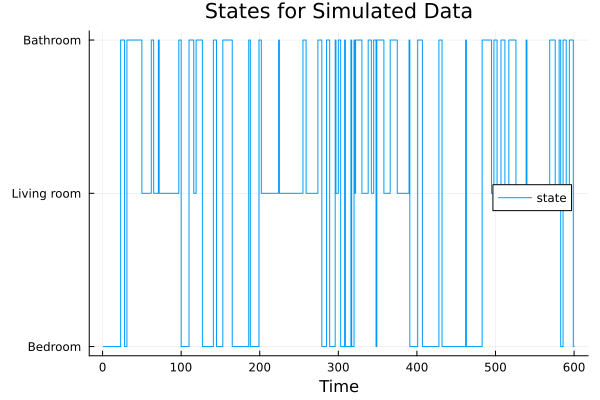

In [10]:
plot(title="States for Simulated Data")
plot!(
    argmax.(_sˣᴿᵒᵒᵐː), linetype=:steppre, linestyle=:solid, leg=:right, 
    label="state", xlabel="Time", yticks=([1,2,3,4], ["Bedroom", "Living room", "Bathroom"]))

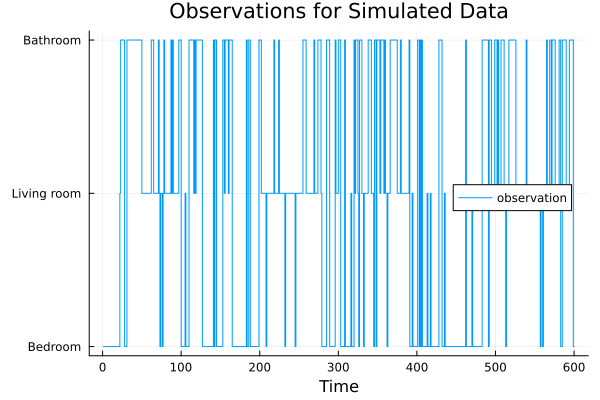

In [11]:
plot(title="Observations for Simulated Data")
plot!(
    argmax.(_oᵀᵉˣᵗᵘʳᵉː), linetype=:steppre, linestyle=:solid, leg=:right, 
    label="observation", xlabel="Time", yticks=([1,2,3], ["Bedroom", "Living room", "Bathroom"]))

### 4.4 Uncertainty Model

The uncertainty model is captured in the transition matrix $\boldsymbol{B}^{*\text{Room}}$ and the observation matrix $\boldsymbol{A}^{*\text{Texture}}$.

### 4.5 Agent / Generative Model

#### 4.5.1 State and Observation variables

On the agent's side, the state of the environment at time $t$ will be given by a (compound) vector $\mathbf{s}_t$ consisting of 1-hot encoded state factor components (here a single component)

$$
\begin{aligned}
\mathbf{s}_t &= (\boldsymbol{s}^{\mathrm{Room}}_{t})
\end{aligned}
$$

where the *state factors* are:

- $\boldsymbol{s}^{\mathrm{Room}}_{t} \in \{\text{bedroom}, \text{livingroom}, \text{bathroom} \} = \{(1, 0, 0), (0, 1, 0), (0, 0, 1) \}$

The *initial state prior* is given by
$$
p(\boldsymbol{s}^{\text{Room}}_{0}) = \mathcal{Cat}(\boldsymbol{s}^{\text{Room}}_{0} ∣ \boldsymbol{d})
$$

where $\boldsymbol{d}$ parameterizes the categorical distribution of $\boldsymbol{s}^{\text{Room}}_0$.

Similarly, the (compound) observation vector for the Roomba at time $t$ will be given by

$$\mathbf{o}_t=  ( \boldsymbol{o}^{\text{Texture}}_t )$$

where the *observation modalities* are:

- $\boldsymbol{o}^{\mathrm{Texture}}_{t} \in \{\text{hardwood}, \text{carpet}, \text{tiles} \} = \{(1, 0, 0), (0, 1, 0), (0, 0, 1) \}$

#### 4.5.2 Decision variables

There will be no decision variables (yet).

#### 4.5.3 Preference variables / Setpoints

There will be no preference variables (yet).

#### 4.5.4 State Transition and Observation Generation functions

The *state transition function* is given by

$$\begin{aligned}
p(\boldsymbol{s}^{\text{Room}}_k ∣ \boldsymbol{s}^{\text{Room}}_{k-1}) &= \mathcal{Cat}(\boldsymbol{s}^{\text{Room}}_k ∣ \boldsymbol{B}^{\text{Room}} \boldsymbol{s}^{\text{Room}}_{k-1})
\end{aligned}$$

where 

$\boldsymbol{B}^{\text{Room}} \boldsymbol{s}^{\text{Room}}_{k-1}$ parameterizes the categorical distribution of $\boldsymbol{s}^{\text{Room}}_k$.

The *observation generation function* is given by

$$\begin{aligned}
p(\boldsymbol{o}^{\text{Texture}}_k ∣ \boldsymbol{s}^{\text{Room}}_k) &= \mathcal{Cat}(\boldsymbol{o}^{\text{Texture}}_k ∣ \boldsymbol{A}^{\text{Texture}} \boldsymbol{s}^{\text{Room}}_k)
\end{aligned}$$

where 

$\boldsymbol{A}^{\text{Texture}} \boldsymbol{s}^{\text{Room}}_k$ parameterizes the categorical distribution of $\boldsymbol{o}^{\text{Texture}}_k$.

An entry in $\boldsymbol{A}^{\text{Texture}}$ captures the probability of a specific *observation* given a specific *state*. Each column in $\boldsymbol{A}^{\text{Texture}}$ contains a categorical distribution. A specific column is selected by multiplying with $\boldsymbol{s}^{\text{Room}}$.

#### 4.5.5 Implementation of the Agent / Generative Model / Internal Model

We start by specifying a probabilistic model for the agent that describes the agent's internal beliefs over the external dynamics of the environment. Assuming the current time is $t$,

The generative model is defined as follows for state factor $n=\text{Room}$ and observation modality $m=\text{Texture}$:

$$\begin{aligned} 
p(\boldsymbol{o^{[m]}_:}, \boldsymbol{s^{[n]}_:}) = 
\underbrace{p(\boldsymbol{s}^{[n]}_{t-1})}_{\substack{\text{Initial} \\ \text{state}     \\ \text{prior}}} 
\prod_{k=t}^{t+T} 
\underbrace{p(\boldsymbol{o}^{[m]}_k \mid \boldsymbol{s}^{[n]}}_k)_{\substack{\text{Observation} \\ \text{model}}} \, 
\underbrace{p(\boldsymbol{s}^{[n]}_k \mid \boldsymbol{s}^{[n]}_{k-1}}_{\substack{\text{Transition}  \\ \text{model}}})
\end{aligned}$$

The generative model includes future time steps.

Setting $t=1$, we have:

$$\begin{aligned}
p(\boldsymbol{o^{[m]}_:}, \boldsymbol{s^{[n]}_:}) &\propto 
\underbrace{p(\boldsymbol{s^{[n]}}_0)}_{\substack{\text{Initial} \\ \text{state} \\ \text{prior}}} \prod_{k=1}^{T+1} 
\underbrace{p(\boldsymbol{o}^{[m]}_k \mid \boldsymbol{s}^{[n]}_k)}_{\substack{\text{Observation} \\ \text{model}}} \, 
\underbrace{p(\boldsymbol{s}^{[n]}_k \mid \boldsymbol{s}^{[n]}_{k-1}}_{\substack{\text{Transition} \\ \text{model}}})
\end{aligned}$$

where

$$\begin{aligned}
p(\boldsymbol{s}^{[n]}_{0})                          &= \mathcal{Cat}(\boldsymbol{s}^{[n]}_{0} ∣ \boldsymbol{d}) \\
p(\boldsymbol{o}^{[m]}_k ∣ \boldsymbol{s}^{[n]}_k)                &= \mathcal{Cat}(\boldsymbol{o}^{[m]}_k ∣ \boldsymbol{A}^{[m]} \boldsymbol{s}^{[n]}_k) \\
p(\boldsymbol{s}^{[n]}_k ∣ \boldsymbol{s}^{[n]}_{k-1}) &= \mathcal{Cat}(\boldsymbol{s}^{[n]}_k ∣ \boldsymbol{B}^{[n]} \boldsymbol{s}^{[n]}_{k-1}) \\
\end{aligned}$$

In general, if $\boldsymbol{a}$ is a 1-hot encoded random variable, and has a *categorical* (aka *multinoulli*) distribution, then

$$p(\boldsymbol{a} ∣ \boldsymbol{\rho}) = \mathcal{Cat}(\boldsymbol{a} ∣ \boldsymbol \rho) = \prod_{i} \rho_i^{a_i}$$

This means the $i$ th component of vector $\boldsymbol{a}$ selects the $i$ th component of the probability vector $\boldsymbol \rho$ of the distribution.

If the probability vector is
$\boldsymbol{\rho} = \begin{bmatrix} 0.05 \\ 0.05 \\ 0.50 \\ 0.10 \\ 0.10 \\ 0.20 \end{bmatrix}$
and the random variable $\boldsymbol{a}$ is
$\boldsymbol{a} = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 1 \\ 0 \\ 0 \end{bmatrix}$

then 
$$
\begin{aligned}
p(a=4 ∣ \boldsymbol{\rho}) &= \prod_{i} \rho_i^{a_i} \\
                            &= (0.05^0)(0.05^0)(0.50^0)(0.10^1)(0.10^0)(0.20^0) \\
                            &= 0.10
\end{aligned}
$$

Now it is time to build our model. As mentioned earlier, we will use Categorical distributions for the states and observations. To learn the $\boldsymbol{A}$ and $\boldsymbol{B}$ matrices we can use `MatrixDirichlet` priors. 

For the $\boldsymbol{B}$-matrix, since we have no apriori idea how the roomba is actually going to move we will assume that it moves randomly. We can represent this by filling our `MatrixDirichlet` prior on $\boldsymbol{B}$ with ones. Remember that this will get updated once we start learning, so it's fine if our initial guess is not quite accurate.

As for the observations, we have good reason to trust our Roomba's measurements. To represent this, we will add large values to the diagonal of our prior on $\boldsymbol{A}$. However, we also acknowledge that the Roomba is not infallible, so we will add some noise on the off-diagonal entries.

Since we will use Variational Inference, we also have to specify inference constraints. We will use a structured variational approximation to the true posterior distribution, where we decouple the variational posterior over the states (`q(_sᴿᵒᵒᵐ₀, _sᴿᵒᵒᵐː)`) from the posteriors over the transition matrices (`q(_Aᵀᵉˣᵗᵘʳᵉ)` and `q(_Bᴿᵒᵒᵐ)`). This dependency decoupling in the approximate posterior distribution ensures that inference is tractable. Let's build the model!

In [15]:
@model function hidden_markov_model(_oᵀᵉˣᵗᵘʳᵉː, T)    
    _Bᴿᵒᵒᵐ ~ MatrixDirichlet(ones(3, 3))
    _Aᵀᵉˣᵗᵘʳᵉ ~ MatrixDirichlet([10.0 1.0 1.0; 
                                 1.0 10.0 1.0; 
                                 1.0 1.0 10.0 ])    
    _sᴿᵒᵒᵐ₀ ~ Categorical(fill(1.0/3.0, 3))
    
    _sᴿᵒᵒᵐₖ₋₁ = _sᴿᵒᵒᵐ₀
    ## for k in eachindex(o)
    for k in 1:T
        _sᴿᵒᵒᵐː[k] ~ Transition(_sᴿᵒᵒᵐₖ₋₁, _Bᴿᵒᵒᵐ)
        _oᵀᵉˣᵗᵘʳᵉː[k] ~ Transition(_sᴿᵒᵒᵐː[k], _Aᵀᵉˣᵗᵘʳᵉ)
        _sᴿᵒᵒᵐₖ₋₁ = _sᴿᵒᵒᵐː[k]
    end
end

@constraints function hidden_markov_model_constraints()
    q(_sᴿᵒᵒᵐ₀, _sᴿᵒᵒᵐː, _Aᵀᵉˣᵗᵘʳᵉ, _Bᴿᵒᵒᵐ) = q(_sᴿᵒᵒᵐ₀, _sᴿᵒᵒᵐː)q(_Aᵀᵉˣᵗᵘʳᵉ)q(_Bᴿᵒᵒᵐ)
end

hidden_markov_model_constraints (generic function with 1 method)

Next, we define the agent and the time-stepping procedure.

In [16]:
function create_agent(; T=20, _sᴿᵒᵒᵐ₀, _oᵀᵉˣᵗᵘʳᵉː)
    compute = (ôₜ::Vector{Float64}) -> begin
        imarginals = @initialization begin
            q(_Aᵀᵉˣᵗᵘʳᵉ) = vague(MatrixDirichlet, 3, 3)
            q(_Bᴿᵒᵒᵐ) = vague(MatrixDirichlet, 3, 3) 
            q(_sᴿᵒᵒᵐː) = vague(Categorical, 3)
        end
        result = infer(
            model=hidden_markov_model(T=T),
            data=(_oᵀᵉˣᵗᵘʳᵉː=_oᵀᵉˣᵗᵘʳᵉː,),
            constraints=hidden_markov_model_constraints(),
            initialization=imarginals,
            returnvars = (    
                _Aᵀᵉˣᵗᵘʳᵉ=KeepLast(),
                _Bᴿᵒᵒᵐ=KeepLast(),
                _sᴿᵒᵒᵐː=KeepLast()
            ),    
            iterations   =20,
            free_energy  =true
        );
    end

    return (compute)
end    

create_agent (generic function with 1 method)

### 4.6 Agent Evaluation

Now it's time to perform inference and find out where the Roomba went in our absence. Did it remember to clean the bathroom?

We'll be using Variational Inference to perform inference, which means we need to set some initial marginals as a starting point. RxInfer makes this easy with the `vague` function, which provides an uninformative guess. If you have better ideas, you can try a different initial guess and see what happens.

Since we're only interested in the final result - the best guess about the Roomba's position - we'll only keep the last results. Let's start the inference process!

#### 4.6.1 Evaluate with simulated data

##### 4.6.1.1 Naive approach {N/A}

##### 4.6.1.2 Active inference approach

In [17]:
### Simulation parameters
## Total simulation time
N = 600

## Lookahead time horizon
## T = 50 ## Lookahead time horizon

## Initial state
_sᴿᵒᵒᵐ₀ = [1.0, 0.0, 0.0]

3-element Vector{Float64}:
 1.0
 0.0
 0.0

In [26]:
### OVERRIDES

Let's take a look at our results. If we're successful, we should have a good idea about the actual layout of the apartment (a good posterior marginal over $\boldsymbol{B}$) and about the uncertainty in the roomba's observations (A good posterior over $\boldsymbol{A}$). Let's see if it worked.

In [18]:
(execute_ai, observe_ai) = create_envir(;
    _Aˣᵀᵉˣᵗᵘʳᵉ=_Aˣᵀᵉˣᵗᵘʳᵉ,
    _Bˣᴿᵒᵒᵐ=_Bˣᴿᵒᵒᵐ,
    _sˣᴿᵒᵒᵐ₀=_sᴿᵒᵒᵐ₀
)
##- _oᵀᵉˣᵗᵘʳᵉː = Vector{Vector{Float64}}(undef, _N) ## Observations
##- ISSUE: UndefRefError (SG)
_oᴿᵒᵒᵐː = Vector{Float64}[ [0.0, 0.0, 0.0] for _ = 1:N ]
(compute_ai) = create_agent(;
    T=N,
    _sᴿᵒᵒᵐ₀=_sᴿᵒᵒᵐ₀,
    _oᵀᵉˣᵗᵘʳᵉː=_oᵀᵉˣᵗᵘʳᵉː ## used by compute() for infer()'s data
)

## Step through experimental protocol
_sᴿᵒᵒᵐː = Vector{Vector{Float64}}(undef, N) ## States
for t = 1:N
    _sᴿᵒᵒᵐː[t] = execute_ai() ## The action influences hidden external states
    _oᵀᵉˣᵗᵘʳᵉː[t] = observe_ai() ## Observe the current environmental outcome (update p)
    compute_ai(_oᵀᵉˣᵗᵘʳᵉː[t])
end

In [19]:
_sᴿᵒᵒᵐː

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [1.0, 0.0, 0.0]

In [20]:
_oᵀᵉˣᵗᵘʳᵉː

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [1.0, 0.0, 0.0]

In [22]:
result = compute_ai([1.0, 0.0, 0.0])
result.posteriors

Dict{Symbol, Any} with 3 entries:
  :_Aᵀᵉˣᵗᵘʳᵉ => MatrixDirichlet{Float64, Matrix{Float64}}(…
  :_sᴿᵒᵒᵐː   => Categorical{Float64, Vector{Float64}}[Categorical{Float64, Vect…
  :_Bᴿᵒᵒᵐ    => MatrixDirichlet{Float64, Matrix{Float64}}(…

In [23]:
println("Posterior Marginal for B:")
BSim_est = mean(result.posteriors[:_Bᴿᵒᵒᵐ])

Posterior Marginal for B:


3×3 Matrix{Float64}:
 0.913718    0.00526069  0.095936
 0.00514957  0.899092    0.118595
 0.0811323   0.0956472   0.785469

This compares well with:
```
_BSim = [
0.9  0.0  0.1;
0.0  0.9  0.1;
0.1  0.1  0.8]
```



In [25]:
println("Posterior Marginal for A:")
ASim_est = mean(result.posteriors[:_Aᵀᵉˣᵗᵘʳᵉ])

Posterior Marginal for A:


3×3 Matrix{Float64}:
 0.932043   0.0528918  0.0258681
 0.0408098  0.893045   0.0547402
 0.0271467  0.0540628  0.919392

This compares well with:
```
_ASim = [
0.9  0.05 0.05;
0.05 0.9  0.05;
0.05 0.05 0.9] 
```

Finally, we can check if we were successful in keeping tabs on our Roomba's whereabouts. We can also check if our model has converged by looking at the Free Energy. 


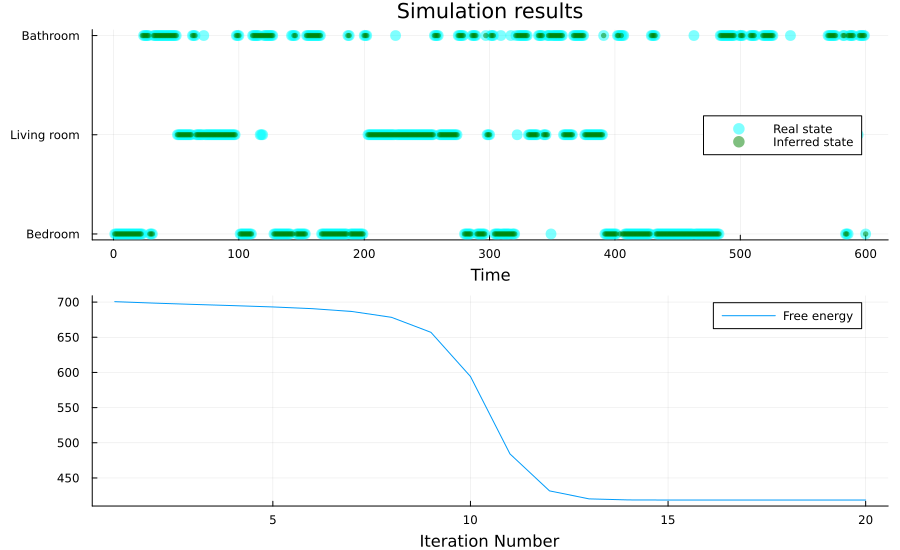

In [26]:
p1 = scatter(argmax.(_sˣᴿᵒᵒᵐː),
    title="Simulation results", 
    label="Real state", 
    legend=:right,
    xlabel="Time" ,
    yticks=([1,2,3],["Bedroom","Living room","Bathroom"]),
    markercolor=:cyan,
    markersize=6,
    markerstrokewidth=0,
    alpha=.5,
    size=(900,550)
)
p1 = scatter!(p1, argmax.(ReactiveMP.probvec.(result.posteriors[:_sᴿᵒᵒᵐː])),
    label="Inferred state",
    markercolor=:green,
    markersize=3,
    markerstrokewidth=0,
    alpha=.5
)
p2 = plot(result.free_energy, 
    label="Free energy",
    xlabel="Iteration Number"
)
plot(p1, p2, layout=@layout([ a; b ]))